# Simulation Diagnostics

`scene.trace()` returns a `SimulationResult` that contains both the per-detector
results and a complete flux budget for the simulation. Understanding this object
is essential for verifying that a simulation is physically correct.

**Flux accounting.** Every watt launched by a source must end up somewhere:

```
total_flux_in = total_flux_detected + total_flux_absorbed
              + total_flux_escaped  + total_flux_lost
```

The `flux_conservation_error` field tells you how well the simulation preserves
energy. Values below 1 × 10⁻⁴ are typical.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    CollimatedSourceConfig, PointSourceConfig,
    IrradianceDetectorConfig,
    LensConfig,
)

spec = Spectrum.monochromatic(0.55)

## 1. Full SimulationResult Structure

In [2]:
scene = NSQScene()
scene.add_source(
    'S', CoordinateSystem(z=-80),
    CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0),
)
scene.add_lens(
    'L', CoordinateSystem(z=0),
    LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7', front_aperture_radius=12.5),
)
# f = 49.1 mm and a 47.4 mm back focal distance put the focus at z = 52.4 mm.
scene.add_detector(
    'D', CoordinateSystem(z=52.4),
    IrradianceDetectorConfig(width=6, height=6, num_pixels_x=128, num_pixels_y=128),
)

result = scene.trace(num_rays=50_000, seed=42)

# Print every field of SimulationResult
print("=== SimulationResult ===")
print(f"  trace_time_sec         : {result.trace_time_sec:.3f} s")
print(f"  num_rays_total         : {result.num_rays_total:,}")
print(f"  num_rays_absorbed      : {result.num_rays_absorbed:,}")
print(f"  num_rays_escaped       : {result.num_rays_escaped:,}")
print(f"  num_rays_flux_killed   : {result.num_rays_flux_killed:,}")
print(f"  num_rays_depth_killed  : {result.num_rays_depth_killed:,}")
print()
print(f"  total_flux_in          : {result.total_flux_in:.6f} W")
print(f"  total_flux_detected    : {result.total_flux_detected:.6f} W")
print(f"  total_flux_absorbed    : {result.total_flux_absorbed:.6f} W")
print(f"  total_flux_escaped     : {result.total_flux_escaped:.6f} W")
print(f"  total_flux_lost        : {result.total_flux_lost:.6f} W")
print(f"  flux_conservation_error: {result.flux_conservation_error:.2e}")
print()
print("  Detectors              :", list(result.detectors.keys()))

=== SimulationResult ===
  trace_time_sec         : 0.108 s
  num_rays_total         : 50,000
  num_rays_absorbed      : 0
  num_rays_escaped       : 4,108
  num_rays_flux_killed   : 0
  num_rays_depth_killed  : 0

  total_flux_in          : 1.000000 W
  total_flux_detected    : 0.917840 W
  total_flux_absorbed    : 0.000000 W
  total_flux_escaped     : 0.082160 W
  total_flux_lost        : 0.000000 W
  flux_conservation_error: 3.05e-16

  Detectors              : ['D']


## 2. Flux Budget Pie Chart

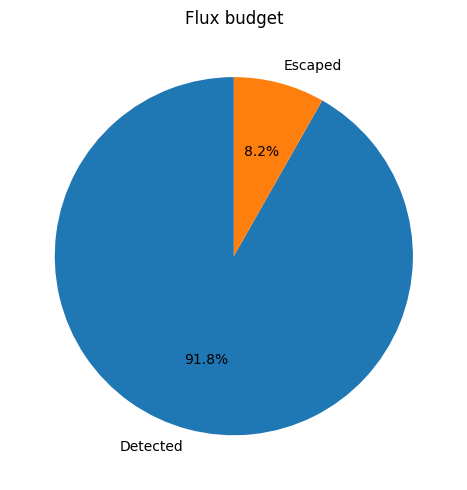

In [3]:
labels = ['Detected', 'Absorbed', 'Escaped', 'Lost']
values = [
    result.total_flux_detected,
    result.total_flux_absorbed,
    result.total_flux_escaped,
    result.total_flux_lost,
]
# Filter out zero categories
labels_filt = [l for l, v in zip(labels, values) if v > 1e-9]
values_filt = [v for v in values if v > 1e-9]

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(values_filt, labels=labels_filt, autopct='%1.1f%%', startangle=90)
ax.set_title('Flux budget')
plt.tight_layout()
plt.show()
plt.close(fig)

## 3. Effect of Ray Count on Accuracy

More rays give a smoother irradiance map and a more reliable flux estimate.
Here we trace the same scene with different ray counts and compare peak irradiance:

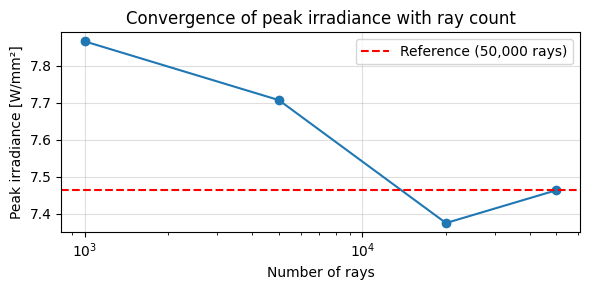

In [4]:
def build_scene():
    s = NSQScene()
    s.add_source('S', CoordinateSystem(z=-80),
                 CollimatedSourceConfig(spectrum=spec, total_flux=1.0, aperture_radius=10.0))
    s.add_lens('L', CoordinateSystem(z=0),
               LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7',
                          front_aperture_radius=12.5))
    s.add_detector('D', CoordinateSystem(z=52.4),
                   IrradianceDetectorConfig(width=6, height=6,
                                            num_pixels_x=64, num_pixels_y=64))
    return s

ray_counts = [1_000, 5_000, 20_000, 50_000]
peaks = []
for n in ray_counts:
    r = build_scene().trace(num_rays=n, seed=42)
    peaks.append(r.detectors['D'].irradiance.max())

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogx(ray_counts, peaks, 'o-')
ax.axhline(peaks[-1], color='r', linestyle='--', label=f'Reference ({ray_counts[-1]:,} rays)')
ax.set_xlabel('Number of rays')
ax.set_ylabel('Peak irradiance [W/mm²]')
ax.set_title('Convergence of peak irradiance with ray count')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
plt.close(fig)

## 4. Controlling Ray Termination

Two parameters decide when a ray stops being traced:

- **`max_depth`** (default 16): a ray is killed after this many surface hits.
  Every interaction counts, so a ray passing through a singlet already uses two
  (front face, back face) before it reaches a detector. Raise it for scenes with
  many internal reflections; lower it to speed up runs where deep bounces do not
  matter.

- **`min_flux_fraction`** (default 1e-6): a ray is killed once its flux falls
  below `min_flux_fraction x initial_per_ray_flux`. Raise it to drop faint rays
  sooner; lower it to keep tracking ghost paths.

Flux removed by either cutoff is reported as `total_flux_lost`, and it is part
of the ledger, so `flux_conservation_error` stays near zero even when rays are
being killed.


In [5]:
# max_depth must be large enough for light to reach the detector at all:
# a singlet needs two hits (front and back face) before the ray gets there.
for max_b in [1, 2, 5, 20]:
    r = build_scene().trace(num_rays=30_000, seed=42,
                            max_depth=max_b, min_flux_fraction=1e-8)
    irr = r.detectors['D']
    print(f"max_depth={max_b:>3}: detected {irr.total_flux:.5f} W  "
          f"({irr.num_rays_hit:>6,} rays)  "
          f"lost={r.total_flux_lost:.5f} W  "
          f"depth_killed={r.num_rays_depth_killed:>6,}  "
          f"err={r.flux_conservation_error:.1e}")


max_depth=  1: detected 0.00000 W  (     0 rays)  lost=1.00000 W  depth_killed=30,000  err=2.2e-16
max_depth=  2: detected 0.00000 W  (     0 rays)  lost=0.95647 W  depth_killed=28,694  err=1.1e-16
max_depth=  5: detected 0.91610 W  (27,483 rays)  lost=0.00103 W  depth_killed=    31  err=4.4e-17
max_depth= 20: detected 0.91607 W  (27,482 rays)  lost=0.00000 W  depth_killed=     0  err=1.5e-16


## 5. Reproducibility with `seed`

Setting `seed` fixes the NumPy random number generator. Two traces with the
same `seed` produce identical results. Omitting `seed` gives a different result
each time (useful for estimating Monte Carlo variance).

In [6]:
r1 = build_scene().trace(num_rays=10_000, seed=7)
r2 = build_scene().trace(num_rays=10_000, seed=7)  # same seed
r3 = build_scene().trace(num_rays=10_000, seed=99) # different seed

f1 = r1.detectors['D'].total_flux
f2 = r2.detectors['D'].total_flux
f3 = r3.detectors['D'].total_flux

print(f"Same seed (7, 7)   : flux1 = {f1:.6f} W,  flux2 = {f2:.6f} W  → identical: {np.isclose(f1, f2)}")
print(f"Diff seed (7, 99)  : flux1 = {f1:.6f} W,  flux3 = {f3:.6f} W  → same: {np.isclose(f1, f3)}")

Same seed (7, 7)   : flux1 = 0.915800 W,  flux2 = 0.915800 W  → identical: True
Diff seed (7, 99)  : flux1 = 0.915800 W,  flux3 = 0.919900 W  → same: False


## 6. Batch Size

`batch_size` sets how many rays are traced in one chunk. It is a **performance
control, not a physical parameter**: the result must not depend on it, beyond
Monte Carlo noise from consuming the random stream differently.

The default of 16,384 rays per batch is tuned so the working set stays in CPU
cache, which is where the trace loop is fastest. Raising it costs speed without
saving memory, and raising it beyond the ray count has no effect at all.
Notebook 10 measures the speed curve directly.


In [7]:
fluxes = {}
for bs in (1_000, 5_000, 20_000, 1_000_000):
    r = build_scene().trace(num_rays=20_000, seed=42, batch_size=bs)
    fluxes[bs] = r.detectors['D'].total_flux
    print(f"batch_size={bs:>9,}: flux = {fluxes[bs]:.6f} W  "
          f"(conservation error {r.flux_conservation_error:.1e})")

spread = max(fluxes.values()) - min(fluxes.values())
print(f"\nSpread across batch sizes: {spread:.2e} W "
      f"({spread / np.mean(list(fluxes.values())) * 100:.2f}% - Monte Carlo noise only)")


batch_size=    1,000: flux = 0.912400 W  (conservation error 3.2e-16)


batch_size=    5,000: flux = 0.917200 W  (conservation error 4.2e-17)
batch_size=   20,000: flux = 0.916750 W  (conservation error 1.9e-16)
batch_size=1,000,000: flux = 0.916750 W  (conservation error 1.9e-16)

Spread across batch sizes: 4.80e-03 W (0.52% - Monte Carlo noise only)


## 7. Diagnostics at a Glance

A compact summary of the three checks worth running on any new scene: does the
flux ledger balance, has the result converged in ray count, and is the beam
where you expect it?


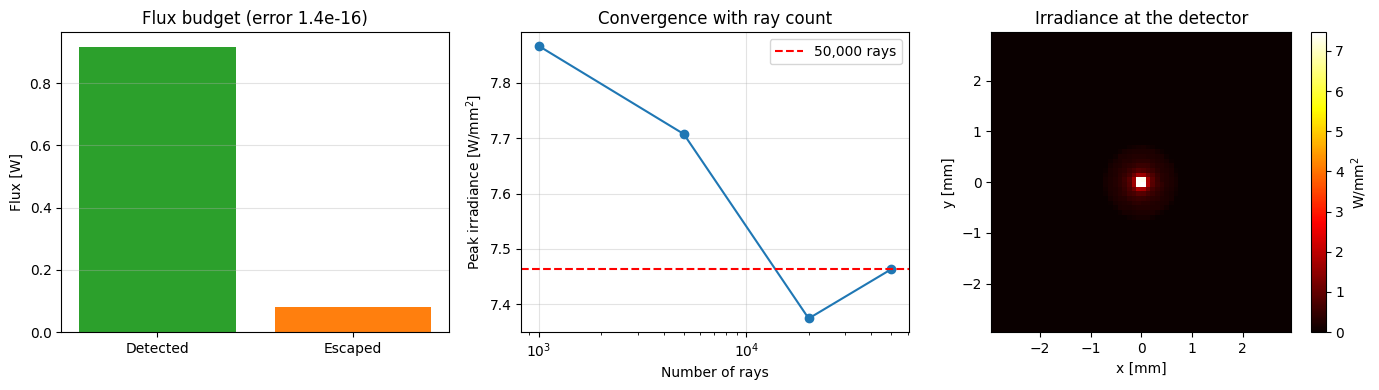

In [8]:
result_final = build_scene().trace(num_rays=50_000, seed=42)
irr_final = result_final.detectors['D']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- flux budget -----------------------------------------------------------
channels = {
    'Detected': result_final.total_flux_detected,
    'Absorbed': result_final.total_flux_absorbed,
    'Escaped': result_final.total_flux_escaped,
    'Lost': result_final.total_flux_lost,
}
present = {k: v for k, v in channels.items() if v > 1e-9}
ax = axes[0]
ax.bar(present.keys(), present.values(), color=['tab:green', 'tab:orange',
                                                'tab:blue', 'tab:red'][:len(present)])
ax.set_ylabel('Flux [W]')
ax.set_title(f'Flux budget (error {result_final.flux_conservation_error:.1e})')
ax.grid(True, axis='y', alpha=0.35)

# --- convergence -----------------------------------------------------------
ax = axes[1]
ax.semilogx(ray_counts, peaks, 'o-')
ax.axhline(peaks[-1], color='r', ls='--', label=f'{ray_counts[-1]:,} rays')
ax.set_xlabel('Number of rays')
ax.set_ylabel('Peak irradiance [W/mm$^2$]')
ax.set_title('Convergence with ray count')
ax.legend()
ax.grid(True, alpha=0.35)

# --- the beam itself -------------------------------------------------------
ax = axes[2]
im = ax.imshow(irr_final.irradiance, origin='lower', cmap='hot',
               extent=[irr_final.x_coords[0], irr_final.x_coords[-1],
                       irr_final.y_coords[0], irr_final.y_coords[-1]])
plt.colorbar(im, ax=ax, label='W/mm$^2$')
ax.set_xlabel('x [mm]')
ax.set_ylabel('y [mm]')
ax.set_title('Irradiance at the detector')

plt.tight_layout()
plt.show()


## Summary

- `SimulationResult` tracks every flux channel: detected, absorbed, escaped, lost
- `flux_conservation_error` validates the ledger and should sit near machine precision
- More rays lower the Monte Carlo noise; watch a key metric converge before trusting it
- `max_depth` must exceed the number of surfaces a ray has to cross, and
  `min_flux_fraction` decides how far faint ghosts are followed
- Use `seed` for reproducible runs; omit it to sample Monte Carlo variance
- `batch_size` affects speed only and must not change the answer
